https://www.kaggle.com/datasets/apollo2506/satellite-imagery-of-ships

Dataset usado
--------
El dataset que usé originalmente estaba erroneamente asignado, que causó un dolor de cabeza horrible

ALERTA LIBRERIAS
------------
La libreria Imgaug se tiene que instalar manualmente desde el repositorio de github directamente:
https://github.com/imaug/imaug/?tab=readme-ov-file#installation

Si se intenta instalar desde pip, se descargará el imgaug original que lleva abandonado decadas (tuve que encontrar el creador diciendolo en un foro hace 11 años para averiguarlo)

In [5]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os, random, cv2, pickle, json, itertools
import imgaug.augmenters as iaa
import imgaug.imgaug
from IPython.display import Image, display

from IPython.display import SVG
from tensorflow.keras.utils import plot_model, model_to_dot
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from collections import Counter
from sklearn.utils import class_weight
from tqdm import tqdm
from sklearn.preprocessing import LabelBinarizer


import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Add, Input, Conv2D, Dropout, Activation, BatchNormalization, MaxPooling2D, ZeroPadding2D, AveragePooling2D, Flatten, Dense)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import *

from tensorflow.keras.utils import load_img

Funciones que se usarán despues

In [160]:
def show_final_history(history):
    
    plt.style.use("ggplot")
    fig, ax = plt.subplots(1,2,figsize=(15,5))
    ax[0].set_title('Loss')
    ax[1].set_title('Accuracy')
    ax[0].plot(history.history['loss'],label='Train Loss')
    ax[0].plot(history.history['val_loss'],label='Validation Loss')
    ax[1].plot(history.history['accuracy'],label='Train Accuracy')
    ax[1].plot(history.history['val_accuracy'],label='Validation Accuracy')
    
    ax[0].legend(loc='upper right')
    ax[1].legend(loc='lower right')
    plt.show()
    pass

In [161]:
def plot_confusion_matrix(cm,classes,title,cmap=plt.cm.Blues):
    
#     np.seterr(divide='ignore',invalid='ignore')
    cm = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
    plt.figure(figsize=(10,10))
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes,rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f'
    thresh = cm.max()/2.
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                horizontalalignment="center",
                color="white" if cm[i,j] > thresh else "black")
        pass
    
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    pass

Aquí se carga el dataset

In [162]:
datasets = ['1']

class_names = ["no-ship","ship"]

class_name_labels = {class_name:i for i,class_name in enumerate(class_names)}

num_classes = len(class_names)
class_name_labels

{'no-ship': 0, 'ship': 1}

In [163]:
def load_data():
    images, labels = [], []
    
    for dataset in datasets:
        
        for folder in os.listdir(dataset):
            label = class_name_labels[folder]
            
            for file in tqdm(os.listdir(os.path.join(dataset,folder))):
                
                img_path = os.path.join(dataset,folder,file)
                
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (48,48))
                
                images.append(img)
                labels.append(label)
                pass
            pass
        
        images = np.array(images,dtype=np.float32)/255.0
        labels = np.array(labels,dtype=np.float32)
        pass
    
    return (images, labels)
    pass

In [164]:
(images, labels) = load_data()
images.shape, labels.shape

100%|██████████| 1000/1000 [00:00<00:00, 2044.19it/s]


((4000, 48, 48, 3), (4000,))

Análisis de variables: El dataset esta muy desbalanceado
--------

In [165]:
n_labels = labels.shape[0]

_, count = np.unique(labels, return_counts=True)

df = pd.DataFrame(data = count)
df['Class Label'] = class_names
df.columns = ['Count','Class-Label']
df.set_index('Class-Label',inplace=True)
df

,Count
Class-Label,
no-ship,3000
ship,1000


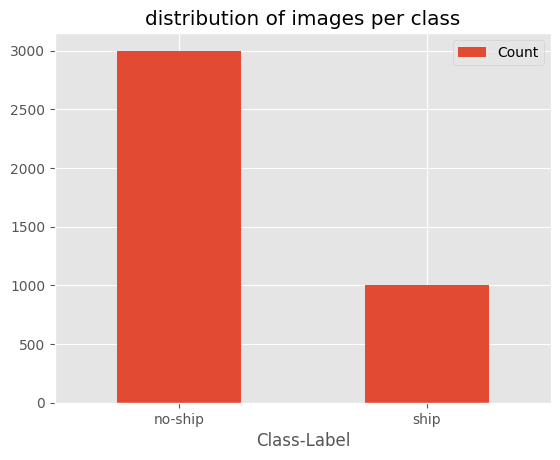

In [166]:
df.plot.bar(rot=0)
plt.title("distribution of images per class");

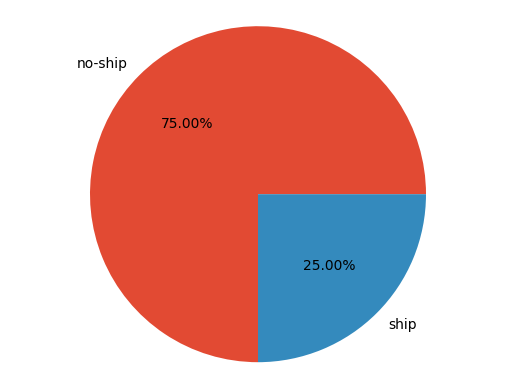

In [167]:
plt.pie(count,
       explode=(0,0),
       labels=class_names,
       autopct="%1.2f%%")
plt.axis('equal');

Como queremos dividir en train, val y test no usamos train_test_split
----------

In [168]:
labels = to_categorical(labels)
np.random.seed(42)
np.random.shuffle(images)
#Misma semilla para que se barajen en parejas
np.random.seed(42)
np.random.shuffle(labels)

total_count = len(images)
total_count

train = int(0.7*total_count)
val = int(0.2*total_count)
test = int(0.1*total_count)

train_images, train_labels = images[:train], labels[:train]
val_images, val_labels = images[train:(val+train)], labels[train:(val+train)]
test_images, test_labels = images[-test:], labels[-test:]

train_images.shape, val_images.shape, test_images.shape

((2800, 48, 48, 3), (800, 48, 48, 3), (400, 48, 48, 3))

Para tratar con desbalanceos altos como este se utiliza la aumentación de imagenes
------------
Originalmente lo conseguí hacer manualmente pero después de muchos dolores de cabezas encontré la librería imgaug. Esto consiste en rotar y trasladar imagenes para crear clones de la clase minoria hasta que lleguen al 50%. Otra alternative con datasets desbalanceados es aumentar los pesos.

In [169]:
AUGMENTATION = True

In [170]:
def augment_add(images, seq, labels):
    
    augmented_images, augmented_labels = [],[]
    for idx,img in tqdm(enumerate(images), total = len(images)):
        
        if np.argmax(labels[idx]) == 1:
            image_aug_1 = seq(image=img)
            image_aug_2 = seq(image=img)
            augmented_images.append(image_aug_1)
            augmented_images.append(image_aug_2)
            augmented_labels.append(labels[idx])
            augmented_labels.append(labels[idx])
    
    augmented_images = np.array(augmented_images, dtype=np.float32)
    augmented_labels = np.array(augmented_labels, dtype=np.float32)
    
    return (augmented_images, augmented_labels)

In [171]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5),
    iaa.Crop(percent=(0,0.1)),
    iaa.LinearContrast((0.75,1.5)),
    iaa.Multiply((0.8,1.2), per_channel=0.2),
    iaa.Affine(
    translate_percent={"x":(-0.2,0.2), "y":(-0.2,0.2)},
    mode="constant",
    cval=0
    )
], random_order=True)

In [172]:
print(train_images.shape)
print(train_labels.shape)

(2800, 48, 48, 3)
(2800, 2)


In [173]:
print(labels)

[[1. 0.]
 [0. 1.]
 [1. 0.]
 ...
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [ ]:
pre_aug = train_images[0]

In [175]:
if AUGMENTATION:
    (aug_images, aug_labels) = augment_add(train_images, seq, train_labels)
    train_images = np.concatenate([train_images, aug_images])
    train_labels = np.concatenate([train_labels, aug_labels])


100%|██████████| 2800/2800 [00:01<00:00, 2085.88it/s]


In [ ]:
cv2.imshow(aug_images[0])

In [111]:
print(train_images.shape)
print(train_labels.shape)

(4172, 48, 48, 3)
(4172, 2)


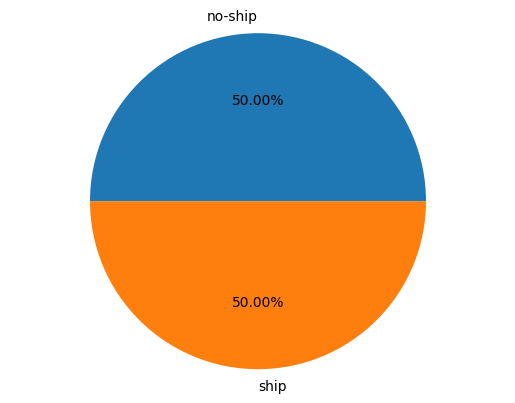

In [112]:
if AUGMENTATION:
    _, count = np.unique(labels, return_counts=True)

    plt.pie(count,
           explode=(0,0),
           labels=class_names,
           autopct="%1.2f%%")
    plt.axis('equal');

In [113]:
np.random.seed(42)
np.random.shuffle(train_images)
#Repetimos el baraje despues de aumentar
np.random.seed(42)
np.random.shuffle(train_labels)

Creación del modelo
-------

In [114]:
def conv_block(X,k,filters,stage,block,s=2):
    
    conv_base_name = 'conv_' + str(stage)+block+'_branch'
    bn_base_name = 'bn_'+str(stage)+block+"_branch"
    
    F1 = filters
    
    X = Conv2D(filters=F1, kernel_size=(k,k), strides=(s,s),
              padding='same',name=conv_base_name+'2a')(X)
    X = BatchNormalization(name=bn_base_name+'2a')(X)
    X = Activation('relu')(X)
    
    return X
    pass        #basicamente un formato que se repite una y otra vez en el modelo hasta que lo saquemos

In [115]:
def basic_model(input_shape,classes):
    
    X_input = Input(input_shape)
    
    X = ZeroPadding2D((5,5))(X_input)
    
    X = Conv2D(16,(3,3),strides=(2,2),name='conv1',padding="same")(X)
    X = BatchNormalization(name='bn_conv1')(X)
    
    # stage 2
    X = conv_block(X,3,32,2,block='A',s=1)
    X = MaxPooling2D((2,2))(X)
    X = Dropout(0.25)(X)

#     Stage 3
    X = conv_block(X,5,32,3,block='A',s=2)
    X = MaxPooling2D((2,2))(X)
    X = Dropout(0.25)(X)
    
#     Stage 4
    X = conv_block(X,3,64,4,block='A',s=1)
    X = MaxPooling2D((2,2))(X)
    X = Dropout(0.25)(X)
    
#   Output Layer
    X = Flatten()(X)
    X = Dense(64)(X)
    X = Dropout(0.5)(X)
    
    X = Dense(128)(X)
    X = Activation("relu")(X)
    
    X = Dense(classes,activation="softmax",name="fc"+str(classes))(X)
    
    model = Model(inputs=X_input,outputs=X,name='Feature_Extraction_and_FC')
    
    return model
    pass

In [116]:
model = basic_model(input_shape=(48,48,3),classes=2)
model.summary()

Model: "Feature_Extraction_and_FC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 58, 58, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 29, 29, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv1 (BatchNormalization)   │ (None, 29, 29, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2A_branch2a (Conv2D)       │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2A_branch2a                  │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3A_branch2a (Conv2D)       │ (None, 7, 7, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3A_branch2a                  │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4A_branch2a (Conv2D)       │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4A_branch2a                  │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,32

 Total params: 62,530 (244.26 KB)

 Trainable params: 62,242 (243.13 KB)

 Non-trainable params: 288 (1.12 KB)

In [117]:
opt = Adam(learning_rate=1e-3)
model.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [118]:
checkpoint = ModelCheckpoint("model_weights.h5",monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')
logs = TensorBoard("logs")

In [119]:
epochs = 50
batch_size = 16

history = model.fit(train_images,train_labels,
                   steps_per_epoch=len(train_images)//batch_size,
                   epochs=epochs,
                   verbose=1, 
                   validation_data=(val_images,val_labels),
                   validation_steps=len(val_images)//batch_size,
                   callbacks=[checkpoint, logs]
                   )

Epoch 1/50
245/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7059 - loss: 0.5523

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.80000, saving model to model_weights.h5



Epoch 1: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8150 - loss: 0.3958 - val_accuracy: 0.8000 - val_loss: 0.4060
Epoch 2/50
241/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9206 - loss: 0.2008
Epoch 2: val_accuracy improved from 0.80000 to 0.94125, saving model to model_weights.h5



Epoch 2: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9235 - loss: 0.1912 - val_accuracy: 0.9413 - val_loss: 0.1748
Epoch 3/50
243/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9510 - loss: 0.1412
Epoch 3: val_accuracy improved from 0.94125 to 0.96000, saving model to model_weights.h5


...


Epoch 6: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9703 - loss: 0.0803 - val_accuracy: 0.9812 - val_loss: 0.0511
Epoch 7/50
241/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9748 - loss: 0.0680
Epoch 7: val_accuracy did not improve from 0.98125
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9717 - loss: 0.0744 - val_accuracy: 0.9438 - val_loss: 0.1174
Epoch 8/50
240/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9765 - loss: 0.0720
Epoch 8: val_accuracy did not improve from 0.98125
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9801 - loss: 0.0605 - val_accuracy: 0.9762 - val_loss: 0.0493
Epoch 9/50
241/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9765 - loss: 0.0590
Epoch 9: val_accuracy did not improve from 0.98125
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9799 - loss: 0.0566 - val_accuracy: 0.9800 - val_loss: 0.0493
Epoch 10/50
242/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.98


Epoch 10: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9813 - loss: 0.0537 - val_accuracy: 0.9825 - val_loss: 0.0623
Epoch 11/50
245/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9824 - loss: 0.0448
Epoch 11: val_accuracy did not improve from 0.98250
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9835 - loss: 0.0440 - val_accuracy: 0.9513 - val_loss: 0.1416
Epoch 12/50
246/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9823 - loss: 0.0546
Epoch 12: val_accuracy did not improve from 0.98250
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9823 - loss: 0.0532 - val_accuracy: 0.9812 - val_loss: 0.0506
Epoch 13/50
243/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9871 - loss: 0.0525
Epoch 13: val_accuracy did not improve from 0.98250
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9861 - loss: 0.0477 - val_accuracy: 0.9400 - val_loss: 0.1501
Epoch 14/50
246/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accurac


Epoch 16: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9868 - loss: 0.0359 - val_accuracy: 0.9837 - val_loss: 0.0461
Epoch 17/50
245/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9922 - loss: 0.0232
Epoch 17: val_accuracy improved from 0.98375 to 0.98875, saving model to model_weights.h5



Epoch 17: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9878 - loss: 0.0320 - val_accuracy: 0.9887 - val_loss: 0.0333
Epoch 18/50
240/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9808 - loss: 0.0481
Epoch 18: val_accuracy did not improve from 0.98875
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9844 - loss: 0.0409 - val_accuracy: 0.9825 - val_loss: 0.0386
Epoch 19/50
243/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9897 - loss: 0.0250
Epoch 19: val_accuracy did not improve from 0.98875
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9897 - loss: 0.0273 - val_accuracy: 0.9787 - val_loss: 0.0638
Epoch 20/50
246/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9920 - loss: 0.0299
Epoch 20: val_accuracy did not improve from 0.98875
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9837 - val_loss: 0.0618
Epoch 21/50
242/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accurac


Epoch 34: finished saving model to model_weights.h5
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9909 - loss: 0.0278 - val_accuracy: 0.9912 - val_loss: 0.0260
Epoch 35/50
246/260 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9959 - loss: 0.0197
Epoch 35: val_accuracy did not improve from 0.99125
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9957 - loss: 0.0183 - val_accuracy: 0.9825 - val_loss: 0.0456
Epoch 36/50
245/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9966 - loss: 0.0131
Epoch 36: val_accuracy did not improve from 0.99125
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9952 - loss: 0.0159 - val_accuracy: 0.9850 - val_loss: 0.0384
Epoch 37/50
246/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9925 - loss: 0.0191
Epoch 37: val_accuracy did not improve from 0.99125
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9930 - loss: 0.0207 - val_accuracy: 0.9787 - val_loss: 0.0660
Epoch 38/50
245/260 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc

In [120]:
model.save_weights('Barcobarquero4.weights.h5')

In [152]:
model.load_weights('Barcobarquero3.weights.h5')

In [148]:
predict = model.predict(val_images)
y_pred = np.argmax(predict, axis=1)
y_true = np.argmax(val_labels, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [149]:
print(classification_report(y_pred, y_true))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       588
           1       0.99      0.96      0.98       212

    accuracy                           0.99       800
   macro avg       0.99      0.98      0.98       800
weighted avg       0.99      0.99      0.99       800



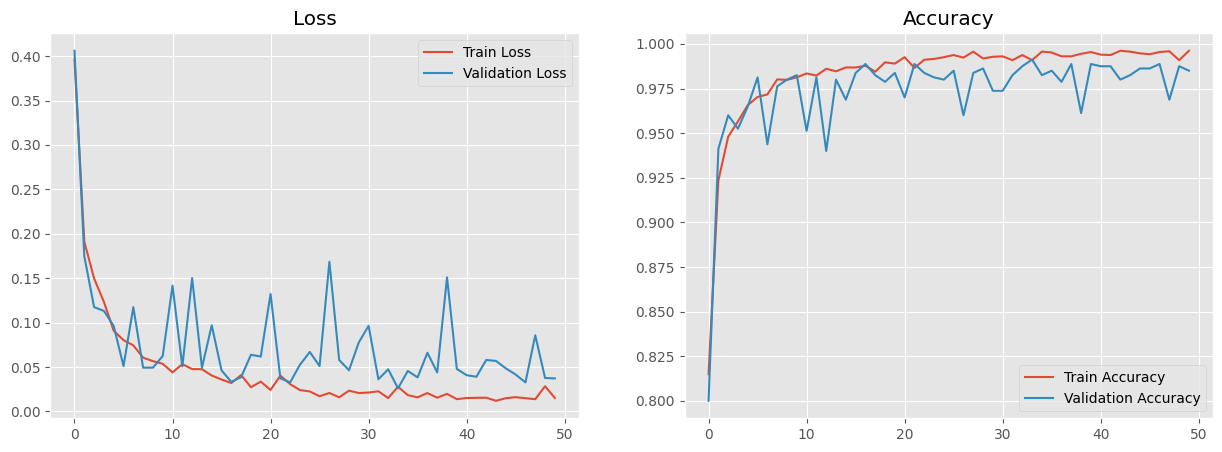

In [124]:
show_final_history(history)

<Figure size 640x480 with 0 Axes>

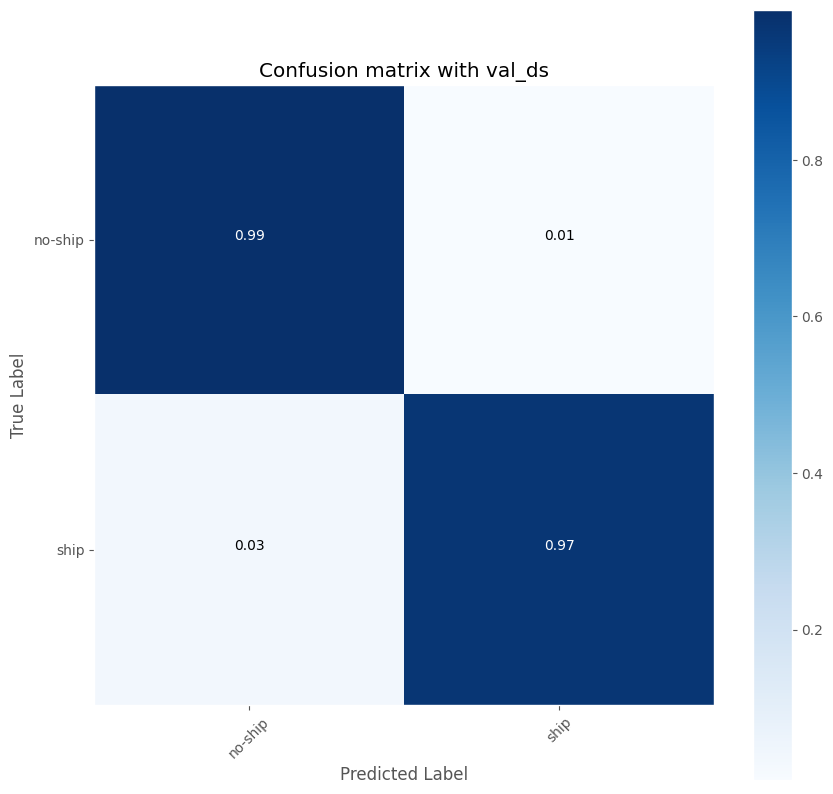

In [126]:
val_actual = np.argmax(val_labels,axis=1)

cnf_mat = confusion_matrix(val_actual, y_pred)
np.set_printoptions(precision=2)

plt.figure()
plot_confusion_matrix(cnf_mat,classes=class_names, title='Confusion matrix with val_ds')
plt.grid(None)
plt.show()

In [150]:
test_pred = model.predict(test_images)
test_pred = np.argmax(test_pred,axis=1)
test_pred.shape

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


(400,)

<Figure size 640x480 with 0 Axes>

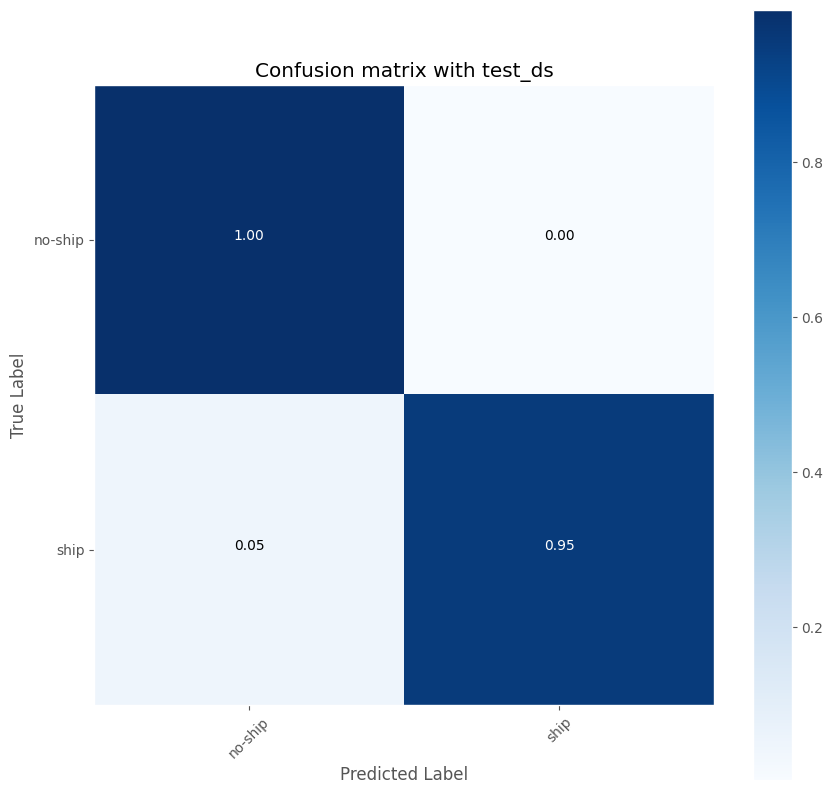

In [128]:
test_actual = np.argmax(test_labels,axis=1)

cnf_mat_test = confusion_matrix(test_actual, test_pred)
np.set_printoptions(precision=2)

plt.figure()
plot_confusion_matrix(cnf_mat_test,classes=class_names, title='Confusion matrix with test_ds')
plt.grid(None)
plt.show()

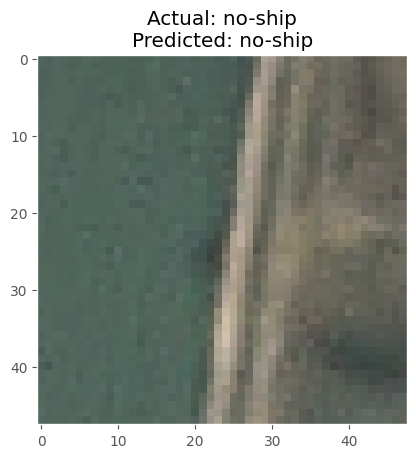

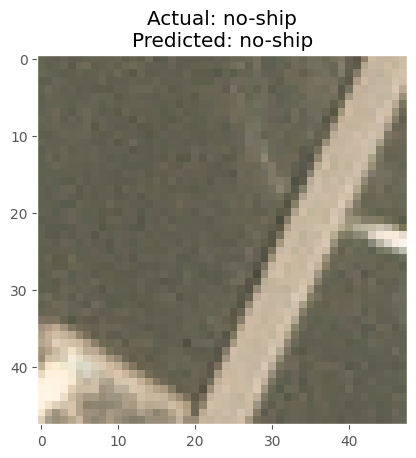

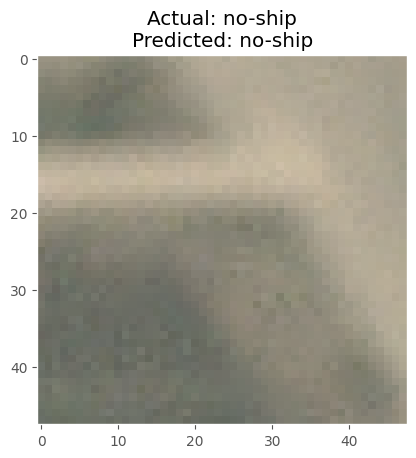

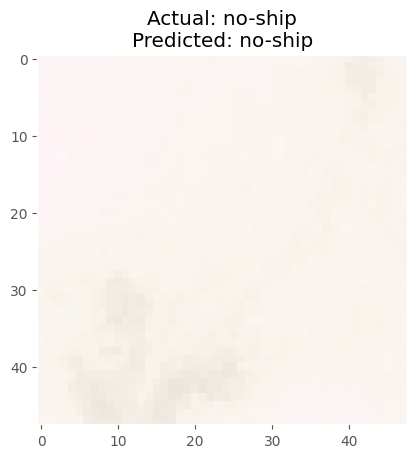

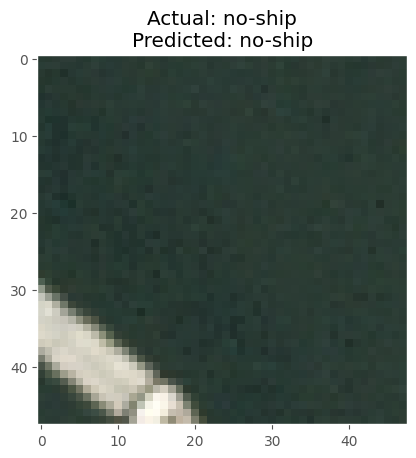

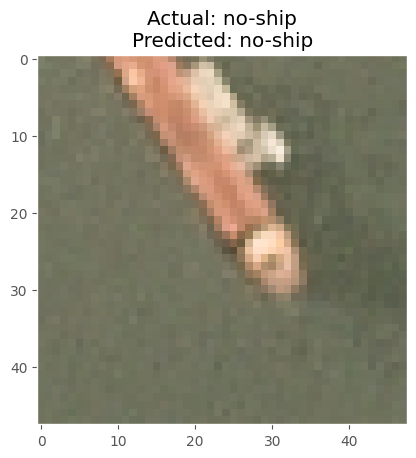

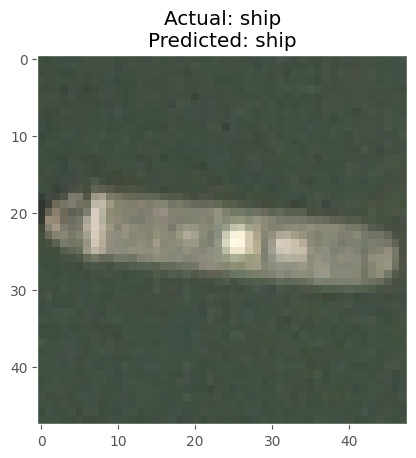

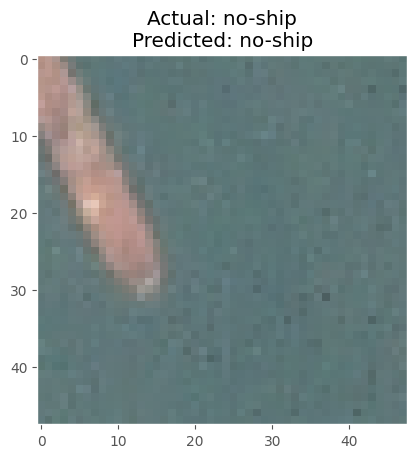

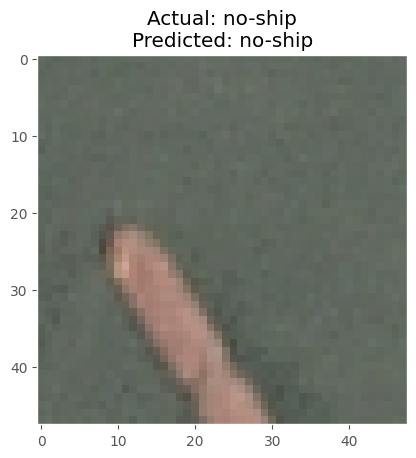

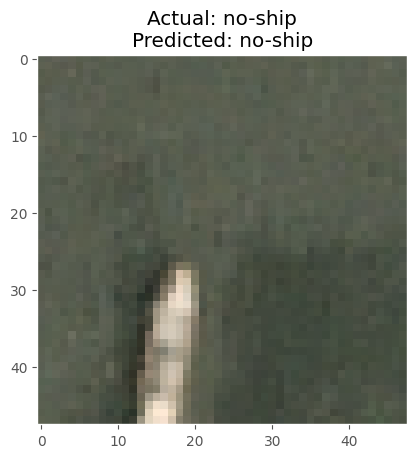

In [151]:
rnd_idx = random.sample(range(0,400),10)

class_labels = {i:class_name for (class_name,i) in class_name_labels.items()}
class_labels

# fig, ax = plt.subplots(2,5,figsize=(5,5))

for i,idx in enumerate(rnd_idx):
    
    plt.imshow(test_images[idx])
    plt.title("Actual: {}\nPredicted: {}".format(class_labels[test_actual[idx]],class_labels[test_pred[idx]]))
    plt.grid(None)
    plt.show()
    pass

Para aplicar explicabilidad GRAD-CAM a las imágenes, tenemos que hacer un mapa de calor sobre la ultima capa de convolución. Por ello se extraerá el nombre de esta capa
-----

In [153]:
model.layers

[<InputLayer name=input_layer_1, built=True>,
 <ZeroPadding2D name=zero_padding2d_1, built=True>,
 <Conv2D name=conv1, built=True>,
 <BatchNormalization name=bn_conv1, built=True>,
 <Conv2D name=conv_2A_branch2a, built=True>,
 <BatchNormalization name=bn_2A_branch2a, built=True>,
 <Activation name=activation_4, built=True>,
 <MaxPooling2D name=max_pooling2d_3, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Conv2D name=conv_3A_branch2a, built=True>,
 <BatchNormalization name=bn_3A_branch2a, built=True>,
 <Activation name=activation_5, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Dropout name=dropout_5, built=True>,
 <Conv2D name=conv_4A_branch2a, built=True>,
 <BatchNormalization name=bn_4A_branch2a, built=True>,
 <Activation name=activation_6, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Dropout name=dropout_6, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_7, built=True>,
 <De

In [154]:
last_layer_name='conv_4A_branch2a'

In [155]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [156]:
def plot_heatmap(image, heatmap, alpha=0.4, cmap="jet", figsize=(6,6)):
    
    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / np.max(heatmap)

    # Apply colormap
    heatmap_color = plt.cm.get_cmap(cmap)(heatmap)[..., :3]

    # Convert image if normalized
    img = image.copy()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)

    # Overlay
    overlay = heatmap_color * 255 * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    # Plot
    plt.figure(figsize=figsize)
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_25']
Received: inputs=Tensor(shape=(1, 48, 48, 3))
  warnings.warn(msg)


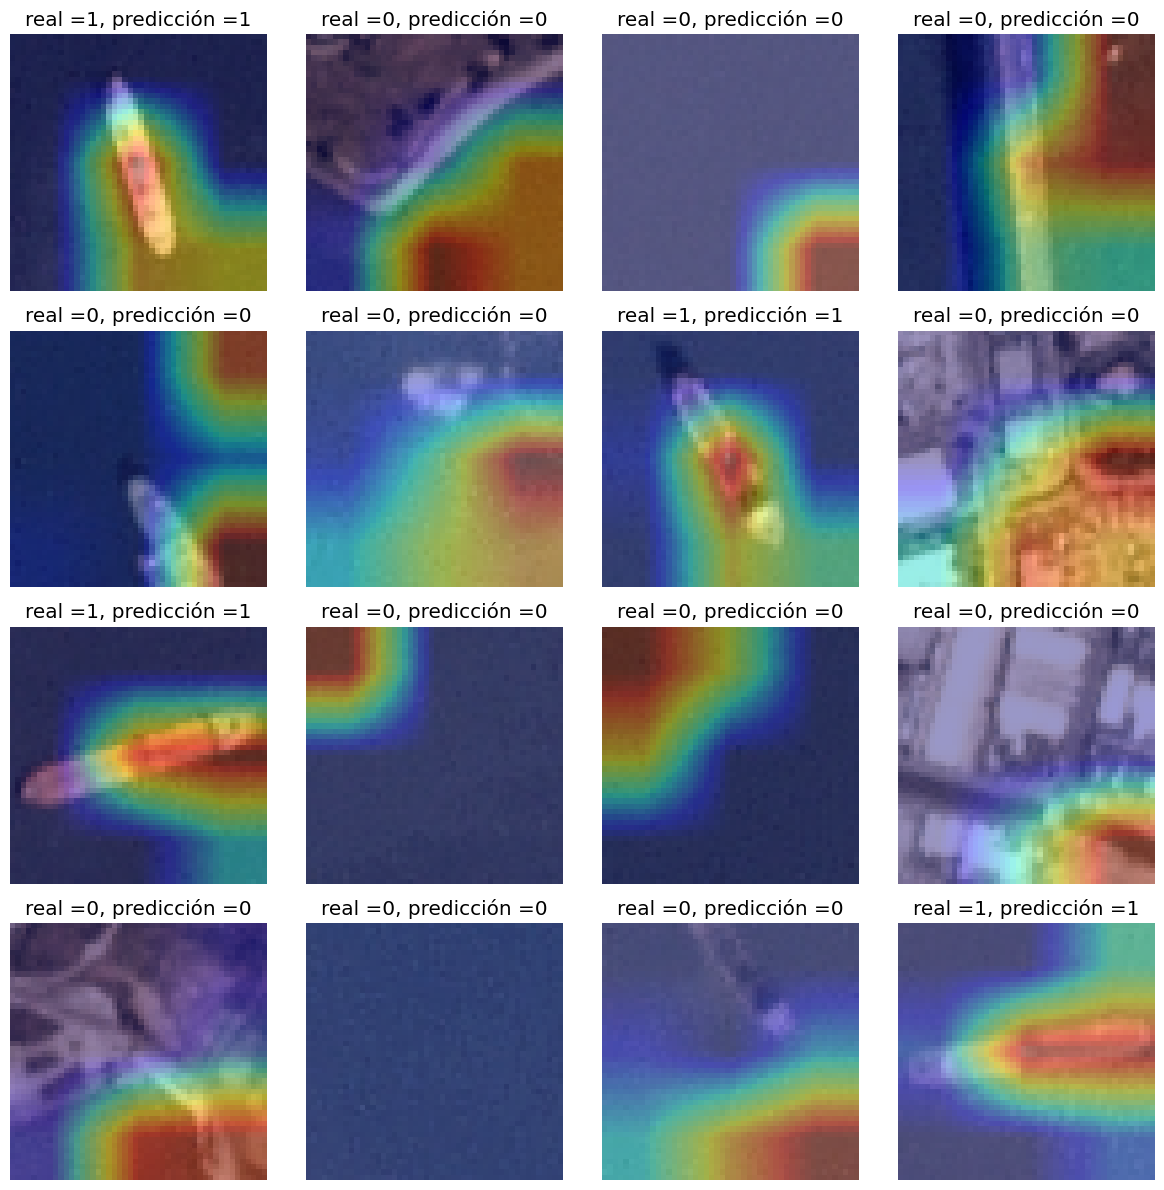

In [157]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat):

    # Get image
    img = test_images[i]
    label = np.argmax(test_labels[i])
    pred = test_pred[i]
    # Add batch dimension
    buffered_img = img[None, ...]

    # Compute Grad-CAM
    heatmap = make_gradcam_heatmap(
        buffered_img,
        model,
        'conv_4A_branch2a'
    )

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    # Colormap
    heatmap_color = plt.cm.jet(heatmap)[..., :3]

    # Prepare image
    if img.max() <= 1.0:
        img_display = (img * 255).astype(np.uint8)
    else:
        img_display = img.copy()

    # Overlay
    overlay = heatmap_color * 255 * 0.4 + img_display * 0.6
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # Plot
    ax.imshow(overlay)
    ax.axis("off")
    ax.set_title('real =' + str(label) + ', predicción =' + str(pred))

plt.tight_layout()
plt.show()